In [3]:
# ==========================================
# STEP 1: Upload Dataset in Google Colab
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving customer_churn_nn.csv to customer_churn_nn.csv
Saving data_dictionary.md to data_dictionary.md


In [4]:
# ==========================================
# STEP 2: Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [5]:
# ==========================================
# STEP 3: Load Dataset
# ==========================================

# Check uploaded files
import os
print(os.listdir())

# Load dataset
df = pd.read_csv("customer_churn_nn.csv")

# Display first 5 rows
df.head()

['.config', 'data_dictionary.md', 'customer_churn_nn.csv', 'sample_data']


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [6]:
# ==========================================
# TASK 1: DATASET UNDERSTANDING
# ==========================================

# Shape
print("Dataset Shape:", df.shape)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

# Missing values
print(df.isnull().sum())

Dataset Shape: (2000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 n

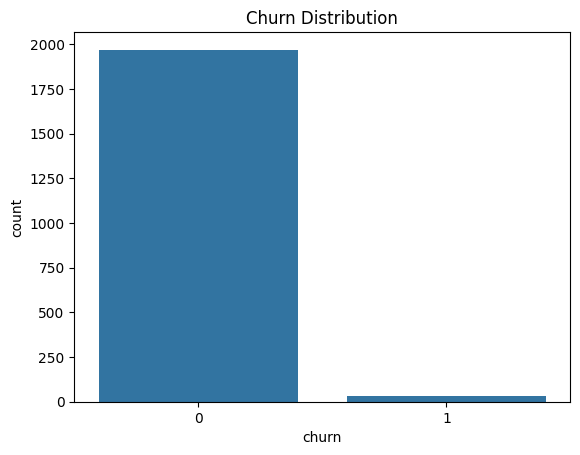

In [7]:
# ==========================================
# TARGET VARIABLE DISTRIBUTION
# ==========================================

sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [8]:
# ==========================================
# TASK 2: DATA PREPROCESSING
# ==========================================

# Separate features and target
X = df.drop(['customer_id', 'churn'], axis=1)
y = df['churn']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['region', 'plan_type', 'contract_type', 'payment_method'], dtype='object')
Numerical Columns: Index(['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count'],
      dtype='object')


In [9]:
# ==========================================
# PREPROCESSING PIPELINES
# ==========================================

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [10]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training Shape:", X_train_processed.shape)
print("Testing Shape:", X_test_processed.shape)

Training Shape: (1600, 28)
Testing Shape: (400, 28)


In [11]:
# ==========================================
# TASK 3: BUILD NEURAL NETWORK MODEL
# ==========================================

model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(
    32,
    activation='relu',
    input_dim=X_train_processed.shape[1]
))

# Hidden Layer 2
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# ==========================================
# COMPILE MODEL
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ==========================================
# TASK 4: TRAIN MODEL
# ==========================================

history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5023 - loss: 0.7406 - val_accuracy: 0.9531 - val_loss: 0.4257
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9711 - loss: 0.2903 - val_accuracy: 0.9937 - val_loss: 0.1538
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.1446 - val_accuracy: 0.9937 - val_loss: 0.0750
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.1065 - val_accuracy: 0.9937 - val_loss: 0.0537
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.0951 - val_accuracy: 0.9937 - val_loss: 0.0461
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.0892 - val_accuracy: 0.9937 - val_loss: 0.0421
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.0856 - val_accuracy: 0.9937 - val_loss: 0.0389
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.0824 - val_accuracy: 0.9937 - val_loss

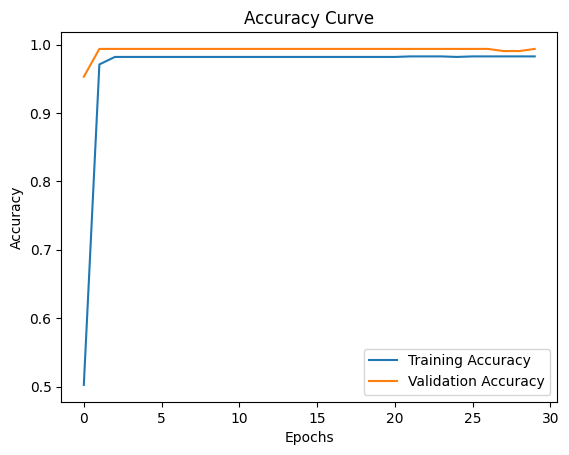

In [14]:
# ==========================================
# PLOT ACCURACY
# ==========================================

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

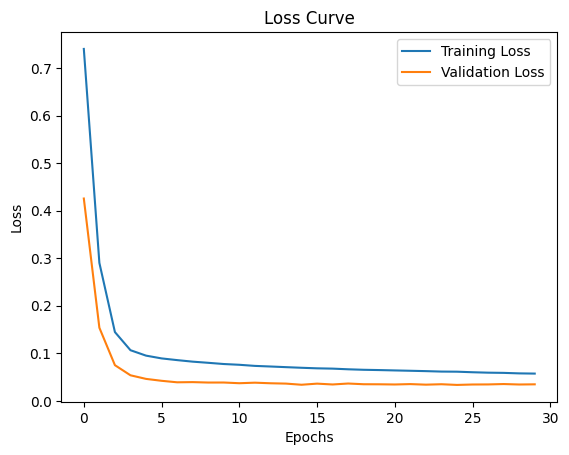

In [15]:
# ==========================================
# PLOT LOSS
# ==========================================

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [16]:
# ==========================================
# EVALUATE MODEL
# ==========================================

loss, accuracy = model.evaluate(X_test_processed, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9850 - loss: 0.0533
Test Loss: 0.05327524617314339
Test Accuracy: 0.9850000143051147


In [17]:
# ==========================================
# PREDICTIONS
# ==========================================

predictions = model.predict(X_test_processed)

predictions = (predictions > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


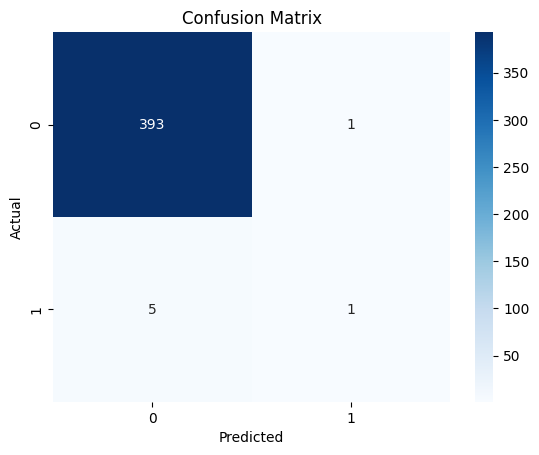

In [18]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [19]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       394
           1       0.50      0.17      0.25         6

    accuracy                           0.98       400
   macro avg       0.74      0.58      0.62       400
weighted avg       0.98      0.98      0.98       400



In [20]:
# ==========================================
# TASK 5: HYPERPARAMETER EXPERIMENTS
# ==========================================

def build_model(neurons=32,
                learning_rate=0.001,
                activation='relu'):

    model = Sequential()

    model.add(Dense(
        neurons,
        activation=activation,
        input_dim=X_train_processed.shape[1]
    ))

    model.add(Dense(neurons // 2, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [21]:
# ==========================================
# EXPERIMENT 1
# ==========================================

model1 = build_model(
    neurons=32,
    learning_rate=0.001,
    activation='relu'
)

history1 = model1.fit(
    X_train_processed,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss1, acc1 = model1.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print("Experiment 1 Accuracy:", acc1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 1 Accuracy: 0.9850000143051147


In [22]:
# ==========================================
# EXPERIMENT 2
# ==========================================

model2 = build_model(
    neurons=64,
    learning_rate=0.001,
    activation='relu'
)

history2 = model2.fit(
    X_train_processed,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss2, acc2 = model2.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print("Experiment 2 Accuracy:", acc2)

Experiment 2 Accuracy: 0.987500011920929


In [23]:
# ==========================================
# EXPERIMENT 3
# ==========================================

model3 = build_model(
    neurons=64,
    learning_rate=0.01,
    activation='tanh'
)

history3 = model3.fit(
    X_train_processed,
    y_train,
    epochs=40,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

loss3, acc3 = model3.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print("Experiment 3 Accuracy:", acc3)

Experiment 3 Accuracy: 0.9825000166893005


In [24]:
# ==========================================
# COMPARISON TABLE
# ==========================================

comparison = pd.DataFrame({
    'Experiment': ['Exp 1', 'Exp 2', 'Exp 3'],
    'Neurons': [32, 64, 64],
    'Learning Rate': [0.001, 0.001, 0.01],
    'Activation': ['relu', 'relu', 'tanh'],
    'Batch Size': [32, 32, 16],
    'Epochs': [20, 30, 40],
    'Accuracy': [acc1, acc2, acc3]
})

comparison

,Experiment,Neurons,Learning Rate,Activation,Batch Size,Epochs,Accuracy
0,Exp 1,32,0.001,relu,32,20,0.9850
1,Exp 2,64,0.001,relu,32,30,0.9875
2,Exp 3,64,0.010,tanh,16,40,0.9825
